In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import expit as inv_logit

df=pd.read_csv('simulated_agent_5k.csv')

cues = ['GW', 'NW', 'GAL', 'NAL']

QGo = {i: 0.0 for i in cues}
QNoGo = {i: 0.0 for i in cues}
SV = {i: 0.0 for i in cues}

In [36]:
params = {
    'xi': 0.1, #noise rate, randomness
    'ep': 0.15, # learning rate
    'b':  0.5, # go bias
    'pi': 1.2, # pavlovian bias
    'rho': 2.0 # reward sensitivity
}

def decide(params, qv_g, qv_ng, sv):
    # sv = stimulus value
    # ep = learning rate
    # rho = rew sensitivity
    # outcome = the rew received this trial (+1,0,1)

    # sv is the stimulus value of the cue itself.
    # It pulls towards Go via pi*sv. 
    #=> a combined effect of pavlovian bias and stimulus value
    # when the cue is avoid, it pulls towards Go via pi*sv.
    # qv = Q value of doing go on this cue
    # qv_ng = Q value of doing nogo on this cue.
    
    b=params['b']
    pi=params['pi']
    wv_g  = qv_g + b + pi * sv # go action weight
    wv_ng = qv_ng  # nogo action weight
    pGo = inv_logit(wv_g - wv_ng)
    pGo = pGo*(1-params['xi'])
    pGo = pGo+(params['xi']/2)
    return pGo
    
float(decide(params, qv_g=0, qv_ng=0.8, sv=0.8))
# setting bias(b) = 3 and sv(cue predicts rew) = 0.8
# we got a strong go bias, ie cue for rew+pav bias is high, means 
# more tendency to go 
# high value of qv_ng implies nogo is correct. 
# the agent will keep making error on conflict trials.

def update (params, sv, qv_g, qv_ng, outcome, pressed):
    sv = sv + params['ep']*(params['rho']*outcome - sv)
    #Q-value update lines
    if (pressed):
        qv_g = qv_g + params['ep']*(params['rho']*outcome-qv_g)
    else:
        qv_ng = qv_ng + params['ep']*(params['rho']*outcome-qv_ng)
    return qv_g, qv_ng, sv



In [37]:
history = []

for _, row in df.iterrows():

    cue = row['Trial_Type']
    qg = QGo[cue]
    qn = QNoGo[cue]
    sv = SV[cue]
    wv_g = qg + params['b'] + params['pi'] * sv
    wv_ng = qn
    pGo = decide(params, qg, qn, sv)

    history.append({
        'Trial': row['Trial'],
        'Cue': cue,
        'QGo': qg,
        'QNoGo': qn,
        'SV': sv,
        'WGo': wv_g,
        'WNoGo': wv_ng,
        'PGo': pGo
    })
    pressed = bool(row['Agent_Choice'])
    reward = row['Agent_Reward']

    qg, qn, sv = update(
        params,
        sv,
        qg,
        qn,
        reward,
        pressed
    )
    QGo[cue] = qg
    QNoGo[cue] = qn
    SV[cue] = sv
history_df = pd.DataFrame(history)

In [38]:
history_df.head()

,Trial,Cue,QGo,QNoGo,SV,WGo,WNoGo,PGo
0,1,NAL,0.0,0.0,0.0,0.50,0.0,0.610213
1,2,NW,0.0,0.0,0.0,0.50,0.0,0.610213
2,3,NW,0.0,0.3,0.3,0.86,0.3,0.622807
3,4,GW,0.0,0.0,0.0,0.50,0.0,0.610213
4,5,GW,0.0,0.0,0.0,0.50,0.0,0.610213


In [39]:
history_df[['Cue','QGo','QNoGo','SV']].head(10)

,Cue,QGo,QNoGo,SV
0,NAL,0.00000,0.0,0.00000
1,NW,0.00000,0.0,0.00000
2,NW,0.00000,0.3,0.30000
3,GW,0.00000,0.0,0.00000
4,GW,0.00000,0.0,0.00000
5,GW,0.30000,0.0,0.30000
6,GW,0.55500,0.0,0.55500
7,NAL,-0.30000,0.0,-0.30000
8,NAL,-0.55500,0.0,-0.55500
9,NAL,-0.77175,0.0,-0.77175


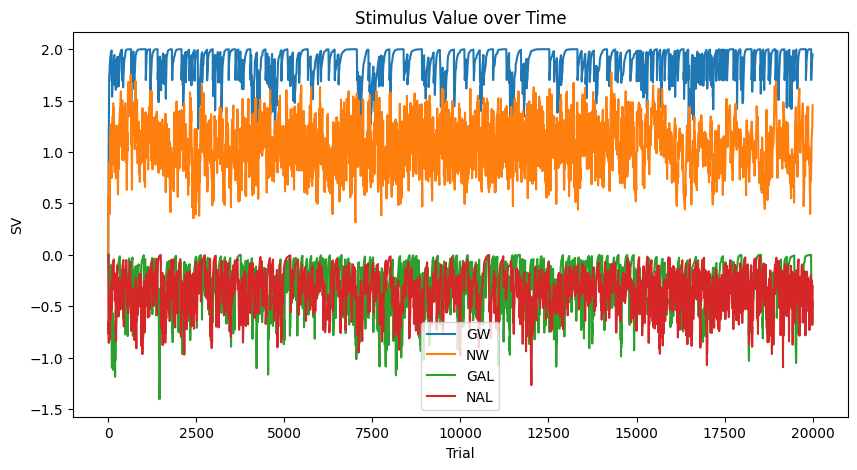

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

for cue in ['GW', 'NW', 'GAL', 'NAL']:

    d = history_df[history_df['Cue'] == cue]

    plt.plot(
        d['Trial'],
        d['SV'],
        label=cue
    )

plt.xlabel("Trial")
plt.ylabel("SV")
plt.title("Stimulus Value over Time")
plt.legend()
plt.show()

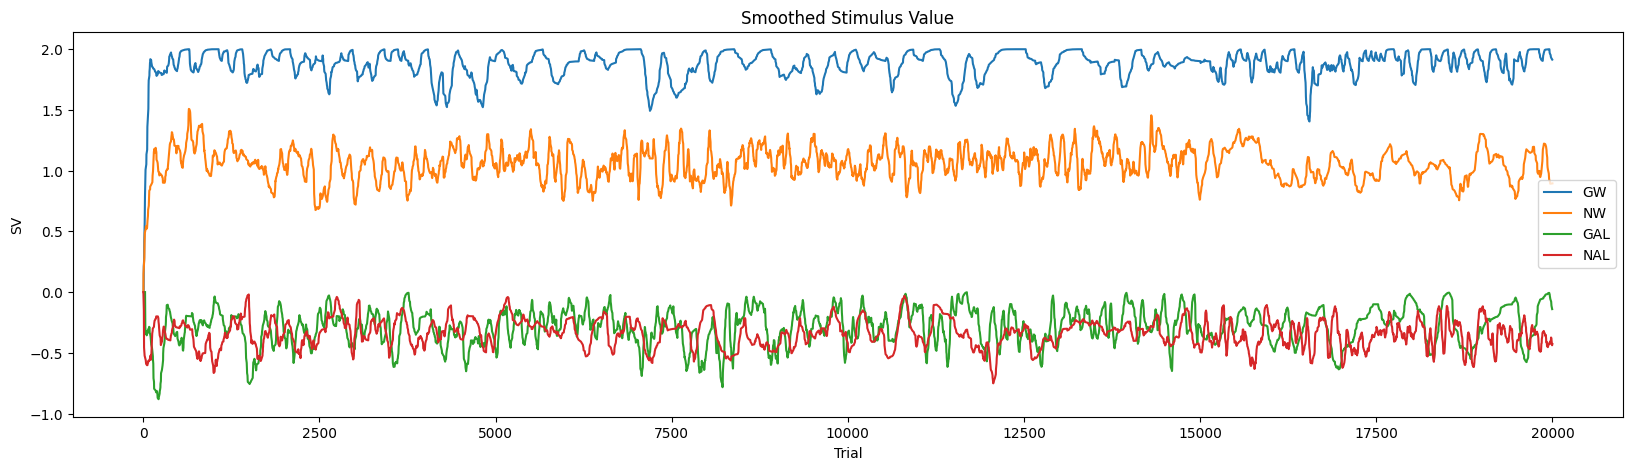

In [44]:
plt.figure(figsize=(20,5))

for cue in ['GW', 'NW', 'GAL', 'NAL']:

    d = history_df[history_df['Cue'] == cue].copy()

    d['SV_smooth'] = d['SV'].rolling(
        window=20,
        min_periods=1
    ).mean()

    plt.plot(
        d['Trial'],
        d['SV_smooth'],
        label=cue
    )

plt.legend()
plt.xlabel("Trial")
plt.ylabel("SV")
plt.title("Smoothed Stimulus Value")
plt.show()

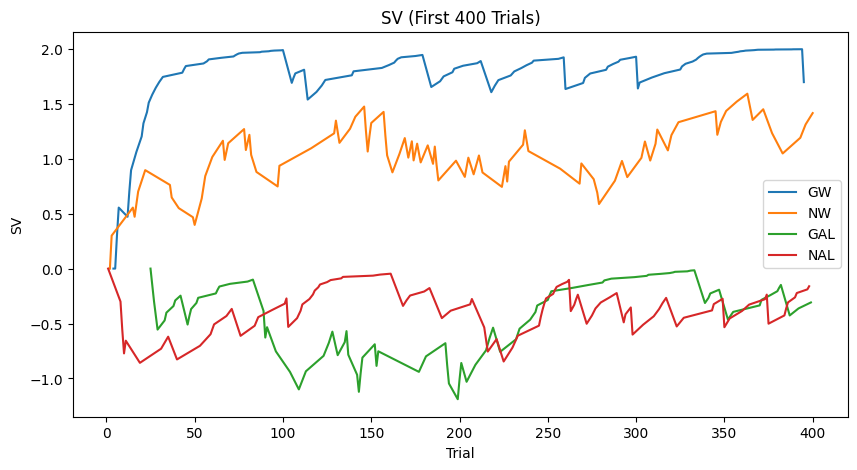

In [47]:
history_small = history_df.iloc[:400]
plt.figure(figsize=(10,5))

for cue in ['GW', 'NW', 'GAL', 'NAL']:

    d = history_small[history_small['Cue'] == cue]

    plt.plot(
        d['Trial'],
        d['SV'],
        label=cue
    )

plt.legend()
plt.xlabel("Trial")
plt.ylabel("SV")
plt.title("SV (First 400 Trials)")
plt.show()

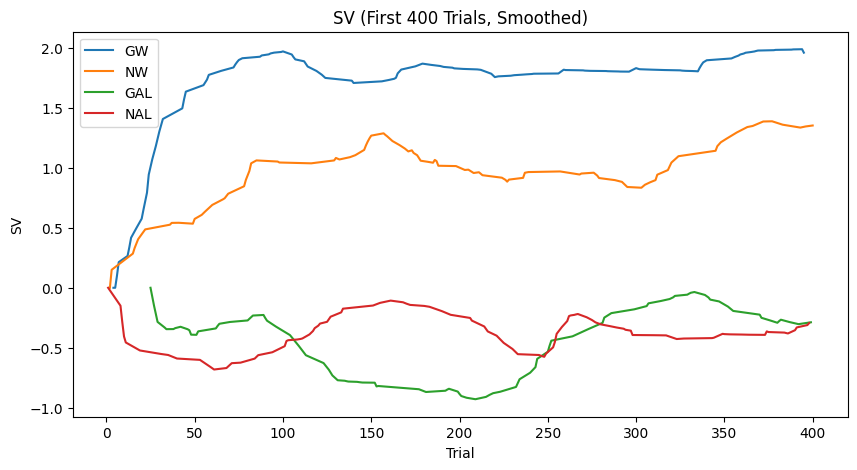

In [48]:
history_small = history_df.iloc[:400]

plt.figure(figsize=(10,5))

for cue in ['GW', 'NW', 'GAL', 'NAL']:

    d = history_small[history_small['Cue'] == cue].copy()

    plt.plot(
        d['Trial'],
        d['SV'].rolling(10, min_periods=1).mean(),
        label=cue
    )

plt.legend()
plt.xlabel("Trial")
plt.ylabel("SV")
plt.title("SV (First 400 Trials, Smoothed)")
plt.show()

In [26]:
row = df.iloc[0]
cue = row['Trial_Type']
choice = int(row['Agent_Choice'])
reward = row['Agent_Reward']

print(cue)
print(choice)
print(reward)

NAL
1
-1.0


In [27]:
qg = QGo[cue]
qn = QNoGo[cue]
sv = SV[cue]
print(qg,qn,sv)


0.0 0.0 0.0


In [30]:
wv_g = qg+params['b']+params['pi']*sv
wv_ng = qn
pGo=decide(params, qg, qn, sv)
print(wv_g)
print(wv_ng)
print(pGo)

0.5
0.0
0.6102133980816692


In [32]:
print(df.columns.tolist())
print(params)
print(QGo)

['Trial', 'Block', 'Conflict', 'Trial_Type', 'Cue_Valence', 'Optimal_Action', 'Agent_Choice', 'Agent_Reward', 'Correct']
{'xi': 0.1, 'ep': 0.15, 'b': 0.5, 'pi': 1.2, 'rho': 2.0}
{'GW': 0.0, 'NW': 0.0, 'GAL': 0.0, 'NAL': 0.0}


In [33]:
row = df.iloc[0]

cue = row['Trial_Type']
choice = int(row['Agent_Choice'])
reward = row['Agent_Reward']

print(cue)
print(choice)
print(reward)

NAL
1
-1.0
